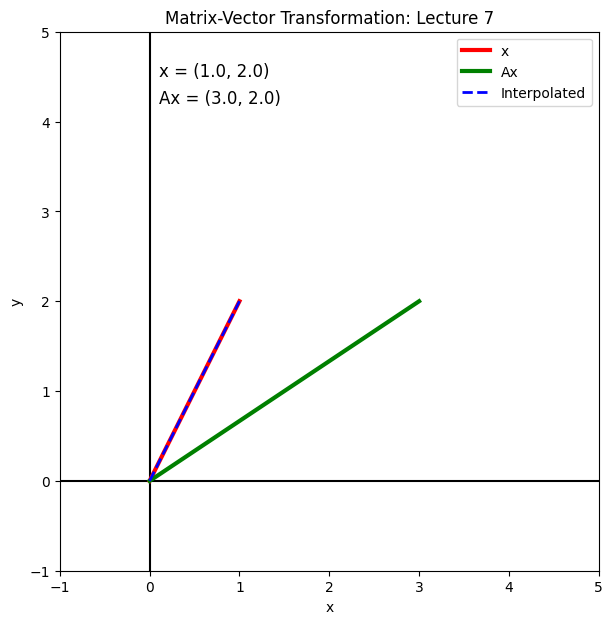

In [1]:
from matplotlib import rc
rc('animation', html='jshtml')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Matrix from Lecture 7 example (a shear)
A = np.array([[1, 1],
              [0, 1]])

# Original vector
x = np.array([1, 2])
Ax = A @ x

# Setup figure
fig, ax = plt.subplots(figsize=(7,7))
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.set_title("Matrix-Vector Transformation: Lecture 7")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Axes
ax.axhline(0, color='black')
ax.axvline(0, color='black')

# Elements to animate
vec_x, = ax.plot([], [], 'r-', linewidth=3, label="x")
vec_Ax, = ax.plot([], [], 'g-', linewidth=3, label="Ax")
moving_vec, = ax.plot([], [], 'b--', linewidth=2, label="Interpolated")

# Labels
label_x = ax.text(0.1, 4.5, "", fontsize=12)
label_Ax = ax.text(0.1, 4.2, "", fontsize=12)

ax.legend()

def update(frame):
    t = frame / 100  # interpolation parameter from 0 to 1

    # Interpolated vector between x and Ax
    interp = (1 - t) * x + t * Ax

    # Update vectors
    vec_x.set_data([0, x[0]], [0, x[1]])
    vec_Ax.set_data([0, Ax[0]], [0, Ax[1]])
    moving_vec.set_data([0, interp[0]], [0, interp[1]])

    # Update labels
    label_x.set_text(f"x = ({x[0]:.1f}, {x[1]:.1f})")
    label_Ax.set_text(f"Ax = ({Ax[0]:.1f}, {Ax[1]:.1f})")

    return vec_x, vec_Ax, moving_vec, label_x, label_Ax

ani = FuncAnimation(fig, update, frames=100, interval=60, blit=False)
ani